<img src="https://elementos.entornos.net/clientes/ISPC/ispc.png" width="350" height="200">

#**TECNICATURA SUPERIOR EN CIENCIAS DE DATOS E INTELIGENCIA ARTIFICIAL**

##**MINERIA DE DATOS**

TERCER AÑO - COHORTE 2024


---

## **ANALISIS DE DATOS EXPLORATORIOS (EDA)**

---

Docente:

Estudiantes:


*  Allende Olmedo Nicolás
*  Direni Carlos
*  García Carlos
*  Guaraz Emanuel
*  Moreno Raúl
*  Testa Andrea Paola
*  Villalba Valeria Nieves


Mayo de 2026

### **OBJETIVO DEL ANÁLISIS**
--------------------
El objetivo de este trabajo es dar inicio a la transformación y puesta a punto del Dataset seleccionado y realizar una
segunda exploración del conjunto de datos climáticos de Argentina, aplicando  las
técnicas de limpieza de registros Nulos, Vacios, Anómalos, Inconcistentes o que presenten Formatos Incorrectos y analizar aquellos Outliers, que puedan sesgar el modelo afectando su capacidad predictiva. Y también, una vez que obtengamos el dataset transformado y limpio, realizar un segundo Análisis Exploratorio de Datos (EDA).

### **ANÁLISIS BIVARIADO Y MULTIVARIADO**
--------------------
En segundo término, utilizar técnica estadística de análisis Bivariado para analizar simultáneamente dos variables "X" y "Y", y determinar si existe o no relación, correlación o dependencia entre ellas. También con la finalidad de identificar Patrones y detectar tendencias, con relación a los datos obtenidos y a la utilidad práctica para nuestro proyecto de la Estación Meteorológica.

### **VISUALIZACIÓN E INTERPRETACIÓN**
--------------------
En tercer lugar, efectuar los gráficos pertinentes, que nos permitan entender de manera más tangible y visual, lo que ocurre con nuestro Dataset atento a la correlación, existente o no, de las variables dependientes e independientes seleccionadas. Y obtener de ellas las conclusiones necesarias para la toma de desiciones vitales para la factible construcción de la Estación.

# **IMPORTAMOS LAS LIBRERÍAS CORRESPONDIENTES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargar el dataset
# df = pd.read_csv('/content/drive/MyDrive/1er Cuatrimestre/Minería de DATOS/Copia de temperature_data_arg_2023.csv')# df = pd.read_csv('/content/drive/MyDrive/1er Cuatrimestre/Minería de DATOS/Copia de temperature_data_arg_2023.csv')
file_id = "1VXftuElZXVknwKWBXJQRpVb2TBVzvCWC"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
resumen_estadistico = df.describe(include='all')
# Ejecutamos describe()
# Usamos include='all' para que también analice las columnas de texto (City, Date)
# Si no lo usas, Pandas solo te mostrará las columnas numéricas.
resumen_estadistico = df.describe(include='all')

# Visualizamos el resultado
print("--- RESUMEN ESTADÍSTICO DEL DATASET ---")
display(resumen_estadistico)


--- RESUMEN ESTADÍSTICO DEL DATASET ---


,Date,City,Max Temperature,Min Temperature,Precipitation,Wind Speed,Relative Humidity
count,1916,1916,1763.000000,1763.000000,1763,1763.000000,1763.000000
unique,438,16,NaN,NaN,299,NaN,NaN
top,11/12/2023,Tucuman,NaN,NaN,0.0,NaN,NaN
freq,7,355,NaN,NaN,1383,NaN,NaN
mean,NaN,NaN,18.533352,9.582530,NaN,24.981906,59.298015
std,NaN,NaN,11.338309,8.767612,NaN,8.637101,17.253238
min,NaN,NaN,2.000000,-50.000000,NaN,10.000000,30.000000
25%,NaN,NaN,12.000000,6.000000,NaN,17.800000,44.400000
50%,NaN,NaN,17.000000,10.000000,NaN,25.000000,58.200000
75%,NaN,NaN,23.000000,15.000000,NaN,32.400000,74.800000


In [ ]:
df.head (11)

,Date,City,Max Temperature,Min Temperature,Precipitation,Wind Speed,Relative Humidity
0,18/9/2023,Rosario,17.0,10.0,93.6,19.0,40.5
1,1/2/2023,Tucuman,26.0,19.0,0.0,35.6,83.4
2,23/11/2023,Cordoba,22.0,15.0,63.3,19.0,35.3
3,26/1/2023,Cordoba,31.0,-50.0,0.0,35.8,57.5
4,18/10/2023,Rosario,22.0,5.0,0.0,33.1,46.0
5,6/10/2023,Rosario,13.0,11.0,16.0,24.3,NaN
6,22/4/2023,Cordoba,17.0,10.0,0.0,39.0,NaN
7,11/1/2023,Cordoba,32.0,NaN,0.0,33.1,38.8
8,27/8/2023,Cordoba,2.0,-2.0,0.0,34.1,42.4
9,2023-09-25,Rosario,24.0,13.0,NaN,19.5,87.6


In [ ]:
df.tail()

,Date,City,Max Temperature,Min Temperature,Precipitation,Wind Speed,Relative Humidity
1911,16/8/2023,Tucuman,8.0,6.0,27.4,36.3,56.3
1912,11/6/2023,Cordoba,7.0,4.0,0.0,21.1,85.1
1913,23/2/2023,Buenos Aires,31.0,21.0,0.0,13.0,74.9
1914,1/4/2023,Cordoba,22.0,11.0,0.0,26.4,86.3
1915,30/1/2023,Buenos Aires,NaN,17.0,0.0,19.5,56.8


**1º Eliminación de celdas y valores nulos sin alterar DataFrame original**

In [ ]:
#Se elimina celdas / filas con valores nulos
df.dropna(inplace=True)

#Se valida si el nuevo df contiene celdas nulas
df.isnull().values.any()

np.False_

**2º Validación de que no existan valores duplicados**

In [ ]:
df.duplicated().sum()

np.int64(35)

**3º Limpieza y preparación de los datos**

### Eliminación de la columna 'Precipitation'

In [ ]:
df.drop('Precipitation', axis=1, inplace=True)

# Verificamos que la columna 'Precipitation' ha sido eliminada
display(df.head())

,Date,City,Max Temperature,Min Temperature,Wind Speed,Relative Humidity
0,18/9/2023,Rosario,17.0,10.0,19.0,40.5
1,1/2/2023,Tucuman,26.0,19.0,35.6,83.4
2,23/11/2023,Cordoba,22.0,15.0,19.0,35.3
3,26/1/2023,Cordoba,31.0,-50.0,35.8,57.5
4,18/10/2023,Rosario,22.0,5.0,33.1,46.0


**4º Detección de Outliers (Valores Atípicos)**

In [ ]:
def detect_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

# Aplicar la detección de outliers a las columnas numéricas relevantes
outliers_max_temp = detect_outliers(df['Max Temperature'])
outliers_min_temp = detect_outliers(df['Min Temperature'])
outliers_wind_speed = detect_outliers(df['Wind Speed'])
outliers_relative_humidity = detect_outliers(df['Relative Humidity'])

print("Outliers en 'Max Temperature':", outliers_max_temp.count())
print("Outliers en 'Min Temperature':", outliers_min_temp.count())
print("Outliers en 'Wind Speed':", outliers_wind_speed.count())
print("Outliers en 'Relative Humidity':", outliers_relative_humidity.count())

Outliers en 'Max Temperature': 14
Outliers en 'Min Temperature': 11
Outliers en 'Wind Speed': 0
Outliers en 'Relative Humidity': 0


In [ ]:
# Limpieza de nombres de columnas
df.columns = df.columns.str.strip()


In [ ]:
# Limpieza Categórica (City)
ciudad_correcciones = {
    'Tucumán': 'Tucuman', 'rosario': 'Rosario', 'Rozario': 'Rosario',
    'Mendosa': 'Mendoza', 'mendoza': 'Mendoza', 'Cba': 'Cordoba',
    'Córdoba': 'Cordoba', 'Cordoba ': 'Cordoba', 'Bunos Aires': 'Buenos Aires',
    'Bs As': 'Buenos Aires', 'buenos aires': 'Buenos Aires'
}
df['City'] = df['City'].replace(ciudad_correcciones)
df = df[df['City'].isin(['Tucuman', 'Rosario', 'Mendoza', 'Cordoba', 'Buenos Aires'])]


In [ ]:
# Transformación de Tipos (Casting)
cols_numericas = ['Max Temperature', 'Min Temperature','Wind Speed', 'Relative Humidity']
for col in cols_numericas:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col].str.extract(r'([-+]?\d*\.?\d+)')[0], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


/tmp/ipykernel_642/4047417239.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [ ]:
# Tratamiento de Outliers
df.loc[df['Max Temperature'] > 50, 'Max Temperature'] = np.nan
df.loc[df['Min Temperature'] < -20, 'Min Temperature'] = np.nan


In [ ]:
# Dataset Final (Eliminación de Nulos para Visualización)
df_final = df.dropna().copy()

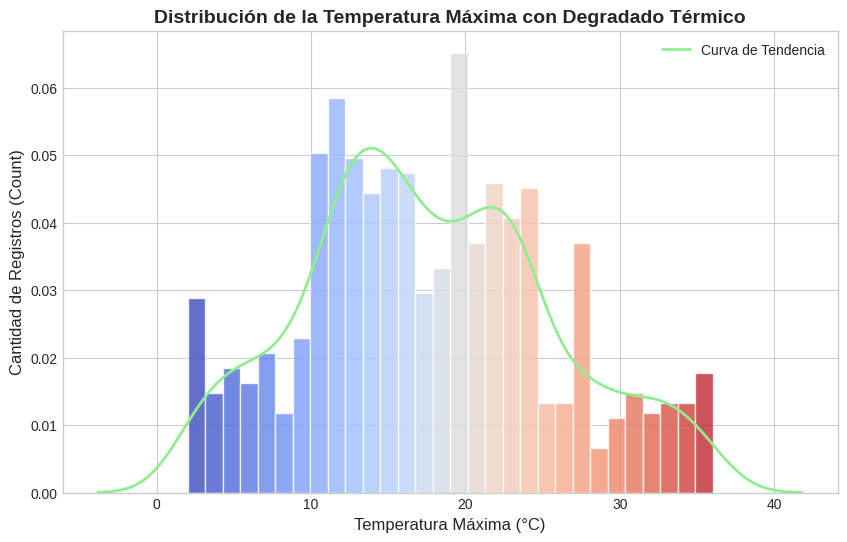

In [ ]:
# --- ANÁLISIS UNIVARIADO CON DEGRADADO TÉRMICO ---
import matplotlib.cm as cm # Importante para el degradado

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# 1. Generamos el histograma y capturamos los 'patches' (las barras)
# Usamos el color 'coral' de base pero luego lo sobreescribimos con el degradado
n, bins, patches = plt.hist(df_final['Max Temperature'], bins=30,
                            edgecolor='white', alpha=0.8, density=True)

# 2. Creamos el degradado (Coolwarm: de azul frío a rojo calor)
# Normalizamos los valores para que el color dependa de la posición en el eje X
col = (bins[:-1] - min(bins)) / (max(bins) - min(bins))
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm.coolwarm(c))

# 3. Agregamos la curva KDE (densidad) por encima
sns.kdeplot(df_final['Max Temperature'], color='lightgreen', linewidth=2, label='Curva de Tendencia')

# 4. Mejoramos el diseño y las etiquetas
plt.title('Distribución de la Temperatura Máxima con Degradado Térmico', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura Máxima (°C)', fontsize=12)
plt.ylabel('Cantidad de Registros (Count)', fontsize=12)

# Añadimos una leyenda para la curva
plt.legend()

plt.show()

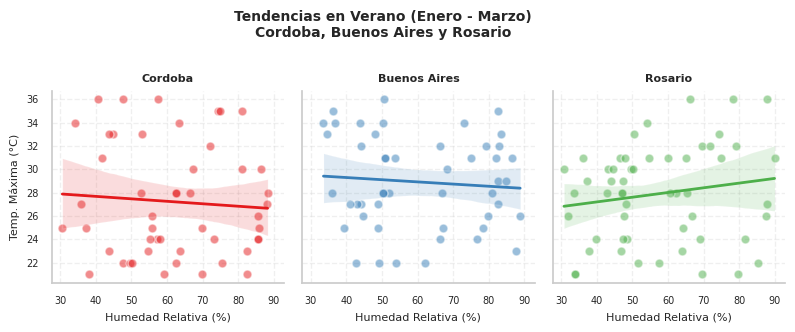

In [ ]:
inicio_estacion = '2023-01-01'
fin_estacion = '2023-03-20'
# --- ANÁLISIS BIVARIADO COMPACTO: TENDENCIAS EN VERANO ---

# 1. Aseguramos el rango de fechas (Estación de Invierno)
inicio_verano = pd.to_datetime('2023-01-01')
fin_verano = pd.to_datetime('2023-03-20')

# 2. Filtramos por Ciudad y Fecha (usamos .copy() para evitar advertencias de pandas)
df_filtrado = df_final[
    (df_final['City'].isin(zonacentro)) &
    (df_final['Date'] >= inicio_verano) &
    (df_final['Date'] <= fin_verano)
].copy()

# 3. Graficamos usando 'col' para separar por ciudad
# Ajustamos height y aspect para que los 3 entren cómodamente en una sola fila
g = sns.lmplot(data=df_filtrado,
                x='Relative Humidity',
                y='Max Temperature',
                hue='City',
                col='City',
                palette='Set1',
                height=3.5,          # Altura reducida para hacerlo compacto
                aspect=0.8,          # Relación de aspecto vertical para que quepan los 3
                scatter_kws={'alpha':0.5, 'edgecolor':'w', 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES ESTÉTICOS DE TAMAÑO (TEXTOS Y EJES) ---

# Títulos de los ejes (X e Y) con tamaño reducido
g.set_axis_labels('Humedad Relativa (%)', 'Temp. Máxima (°C)', size=8)

# Títulos de cada panel (Nombres de las ciudades) en negrita y tamaño 8
g.set_titles("{col_name}", size=8, fontweight='bold')

# Título principal del gráfico (ajustamos la posición con subplots_adjust)
plt.subplots_adjust(top=0.75)
g.fig.suptitle('Tendencias en Verano (Enero - Marzo)\nCordoba, Buenos Aires y Rosario',
               fontsize=10, fontweight='bold')

# 4. Ajustes aplicados a CADA uno de los 3 subgráficos
for ax in g.axes.flat:
    # Agregamos la cuadrícula suave
    ax.grid(True, linestyle='--', alpha=0.3)

    # ACHICAMOS LOS VALORES DE LA CUADRÍCULA (Números de los ejes)
    # axis='both' aplica a X e Y; labelsize=7 es el tamaño pequeño que buscábamos
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()

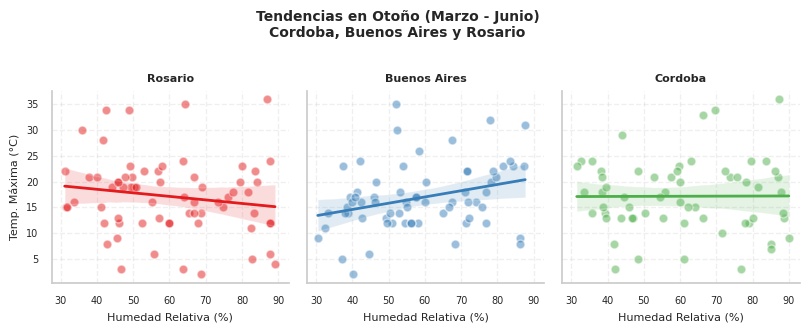

In [ ]:
# --- ANÁLISIS BIVARIADO COMPACTO: TENDENCIAS EN OTOÑO ---

# 1. Aseguramos el rango de fechas (Estación de Otoño)
inicio_otoño = pd.to_datetime('2023-03-21')
fin_otoño = pd.to_datetime('2023-06-20')

# 2. Filtramos por Ciudad y Fecha (usamos .copy() para evitar advertencias de pandas)
df_filtrado = df_final[
    (df_final['City'].isin(zonacentro)) &
    (df_final['Date'] >= inicio_otoño) &
    (df_final['Date'] <= fin_otoño)
].copy()

# 3. Graficamos usando 'col' para separar por ciudad
# Ajustamos height y aspect para que los 3 entren cómodamente en una sola fila
g = sns.lmplot(data=df_filtrado,
                x='Relative Humidity',
                y='Max Temperature',
                hue='City',
                col='City',
                palette='Set1',
                height=3.5,          # Altura reducida para hacerlo compacto
                aspect=0.8,          # Relación de aspecto vertical para que quepan los 3
                scatter_kws={'alpha':0.5, 'edgecolor':'w', 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES ESTÉTICOS DE TAMAÑO (TEXTOS Y EJES) ---

# Títulos de los ejes (X e Y) con tamaño reducido
g.set_axis_labels('Humedad Relativa (%)', 'Temp. Máxima (°C)', size=8)

# Títulos de cada panel (Nombres de las ciudades) en negrita y tamaño 8
g.set_titles("{col_name}", size=8, fontweight='bold')

# Título principal del gráfico (ajustamos la posición con subplots_adjust)
plt.subplots_adjust(top=0.75)
g.fig.suptitle('Tendencias en Otoño (Marzo - Junio)\nCordoba, Buenos Aires y Rosario',
               fontsize=10, fontweight='bold')

# 4. Ajustes aplicados a CADA uno de los 3 subgráficos
for ax in g.axes.flat:
    # Agregamos la cuadrícula suave
    ax.grid(True, linestyle='--', alpha=0.3)

    # ACHICAMOS LOS VALORES DE LA CUADRÍCULA (Números de los ejes)
    # axis='both' aplica a X e Y; labelsize=7 es el tamaño pequeño que buscábamos
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()

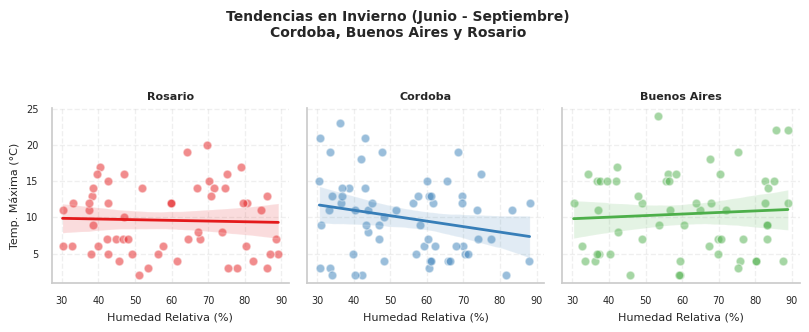

In [ ]:
# --- ANÁLISIS BIVARIADO COMPACTO: TENDENCIAS EN INVIERNO ---

# 1. Aseguramos el rango de fechas (90 días de Invierno)
inicio_invierno = pd.to_datetime('2023-06-21')
fin_invierno = pd.to_datetime('2023-09-20')

# 2. Filtramos por Ciudad y Fecha
df_filtrado = df_final[
    (df_final['City'].isin(zonacentro)) &
    (df_final['Date'] >= inicio_invierno) &
    (df_final['Date'] <= fin_invierno)
].copy()

# 3. Graficamos usando 'col' para separar por ciudad
# Ajustamos height y aspect para que los 3 entren en una fila
g = sns.lmplot(data=df_filtrado,
                x='Relative Humidity',
                y='Max Temperature',
                hue='City',
                col='City',
                palette='Set1',
                height=3.5,          # Altura pequeña
                aspect=0.8,          # Formato vertical para que quepan los 3
                scatter_kws={'alpha':0.5, 'edgecolor':'w', 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES ESTÉTICOS DE TAMAÑO ---

# Títulos de los ejes (Humedad y Temperatura)
g.set_axis_labels('Humedad Relativa (%)', 'Temp. Máxima (°C)', size=8)

# Títulos de cada panel (Nombres de las ciudades)
g.set_titles("{col_name}", size=8, fontweight='bold')

# Título principal del gráfico
plt.subplots_adjust(top=0.7) # Espacio para el título
g.fig.suptitle('Tendencias en Invierno (Junio - Septiembre)\nCordoba, Buenos Aires y Rosario',
               fontsize=10, fontweight='bold')

# 4. Ajustes finos dentro de cada subgráfico (Cuadrícula y Números)
for ax in g.axes.flat:
    # Cuadrícula suave
    ax.grid(True, linestyle='--', alpha=0.3)

    # ACHICAR LOS VALORES DE LA CUADRÍCULA (Números de los ejes)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()

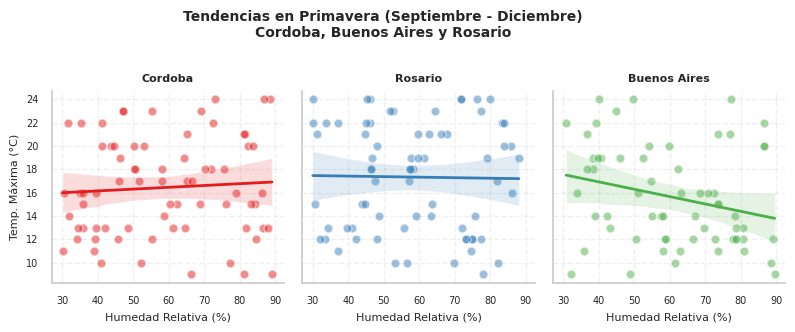

In [ ]:
# --- ANÁLISIS BIVARIADO COMPACTO: TENDENCIAS EN PRIMAVERA ---

# 1. Aseguramos el rango de fechas (Estación de Primavera)
inicio_primavera= pd.to_datetime('2023-09-21')
fin_primavera = pd.to_datetime('2023-12-31')

# 2. Filtramos por Ciudad y Fecha (usamos .copy() para evitar advertencias de pandas)
df_filtrado = df_final[
    (df_final['City'].isin(zonacentro)) &
    (df_final['Date'] >= inicio_primavera) &
    (df_final['Date'] <= fin_primavera)
].copy()

# 3. Graficamos usando 'col' para separar por ciudad
# Ajustamos height y aspect para que los 3 entren cómodamente en una sola fila
g = sns.lmplot(data=df_filtrado,
                x='Relative Humidity',
                y='Max Temperature',
                hue='City',
                col='City',
                palette='Set1',
                height=3.5,          # Altura reducida para hacerlo compacto
                aspect=0.8,          # Relación de aspecto vertical para que quepan los 3
                scatter_kws={'alpha':0.5, 'edgecolor':'w', 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES ESTÉTICOS DE TAMAÑO (TEXTOS Y EJES) ---

# Títulos de los ejes (X e Y) con tamaño reducido
g.set_axis_labels('Humedad Relativa (%)', 'Temp. Máxima (°C)', size=8)

# Títulos de cada panel (Nombres de las ciudades) en negrita y tamaño 8
g.set_titles("{col_name}", size=8, fontweight='bold')

# Título principal del gráfico (ajustamos la posición con subplots_adjust)
plt.subplots_adjust(top=0.75)
g.fig.suptitle('Tendencias en Primavera (Septiembre - Diciembre)\nCordoba, Buenos Aires y Rosario',
               fontsize=10, fontweight='bold')

# 4. Ajustes aplicados a CADA uno de los 3 subgráficos
for ax in g.axes.flat:
    # Agregamos la cuadrícula suave
    ax.grid(True, linestyle='--', alpha=0.3)

    # ACHICAMOS LOS VALORES DE LA CUADRÍCULA (Números de los ejes)
    # axis='both' aplica a X e Y; labelsize=7 es el tamaño pequeño que buscábamos
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()

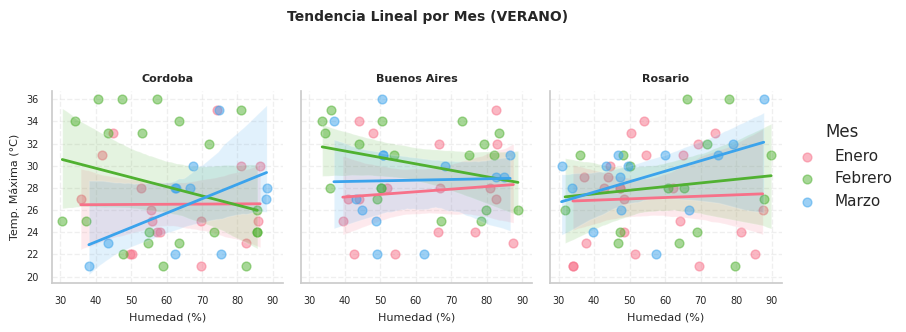

In [ ]:
# --- ANÁLISIS POR MESES ---

# 1. Aseguramos formato datetime
df_final['Date'] = pd.to_datetime(df_final['Date'])

# 2. Diccionario para traducir meses de inglés a español
traduccion_meses = {
    'January': 'Enero', 'February': 'Febrero', 'March': 'Marzo',
    'April': 'Abril', 'May': 'Mayo', 'June': 'Junio',
    'July': 'Julio', 'August': 'Agosto', 'September': 'Septiembre',
    'October': 'Octubre', 'November': 'Noviembre', 'December': 'Diciembre'
}

# Creamos la columna Month y aplicamos la traducción
df_final['Month'] = df_final['Date'].dt.month_name().map(traduccion_meses)

# 3. Definimos el rango y filtramos
inicio_estacion = '2023-01-01'
fin_estacion = '2023-03-20'

df_90dias = df_final[
    (df_final['City'].isin(['Cordoba', 'Buenos Aires', 'Rosario'])) &
    (df_final['Date'] >= inicio_estacion) &
    (df_final['Date'] <= fin_estacion)
].copy()

# 4. Graficamos con los ajustes de tamaño compacto
g = sns.lmplot(data=df_90dias,
                x='Relative Humidity',
                y='Max Temperature',
                hue='Month',
                col='City',
                palette='husl',
                height=3.5, aspect=0.8, # Tamaño compacto para que entren los 3
                scatter_kws={'alpha':0.5, 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES DE TAMAÑO Y ETIQUETAS ---
g.set_axis_labels('Humedad (%)', 'Temp. Máxima (°C)', size=8)
g.set_titles("{col_name}", size=8, fontweight='bold')

plt.subplots_adjust(top=0.75)
g.fig.suptitle('Tendencia Lineal por Mes (VERANO)',
               fontsize=10, fontweight='bold')

# Mejorar la leyenda (Meses en español)
g._legend.set_title("Mes")

# Ajuste de los valores de la cuadrícula (números de los ejes)
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()


En Enero la relación era muy fuerte (línea muy inclinada), pero en Marzo la temperatura fue más estable frente a la humedad (línea más plana).

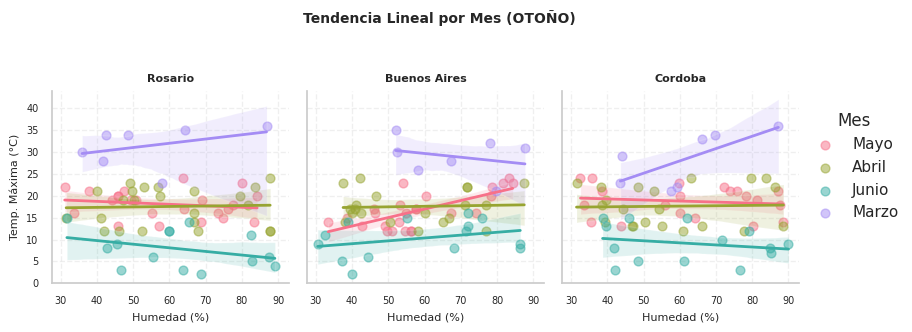

In [ ]:
# --- ANÁLISIS DE OTOÑO ---

# 1. Aseguramos formato datetime
df_final['Date'] = pd.to_datetime(df_final['Date'])

# 2. Diccionario para traducir meses
traduccion_meses = {
    'March': 'Marzo', 'April': 'Abril',
    'May': 'Mayo', 'June': 'Junio'
}

# Creamos la columna Month y aplicamos la traducción
df_final['Month'] = df_final['Date'].dt.month_name().map(traduccion_meses)

# 3. Filtramos por Ciudad y el rango de Otoño (20 de Marzo a 20 de Junio)
inicio_estacion = '2023-03-20'
fin_estacion = '2023-06-20'

df_90dias = df_final[
    (df_final['City'].isin(['Cordoba', 'Buenos Aires', 'Rosario'])) &
    (df_final['Date'] >= inicio_estacion) &
    (df_final['Date'] <= fin_estacion)
].copy()

# 4. Graficamos: Una columna por Ciudad, colores por Mes
g = sns.lmplot(data=df_90dias,
                x='Relative Humidity',
                y='Max Temperature',
                hue='Month',
                col='City',
                palette='husl',
                height=3.5, aspect=0.8, # Tamaño compacto coherente con los anteriores
                scatter_kws={'alpha':0.5, 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES ESTÉTICOS FINALES ---
g.set_axis_labels('Humedad (%)', 'Temp. Máxima (°C)', size=8)
g.set_titles("{col_name}", size=8, fontweight='bold')

plt.subplots_adjust(top=0.75)
g.fig.suptitle('Tendencia Lineal por Mes (OTOÑO)',
               fontsize=10, fontweight='bold')

# Mejorar la leyenda
g._legend.set_title("Mes")

# Ajuste de los valores de la cuadrícula (números pequeños)
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()

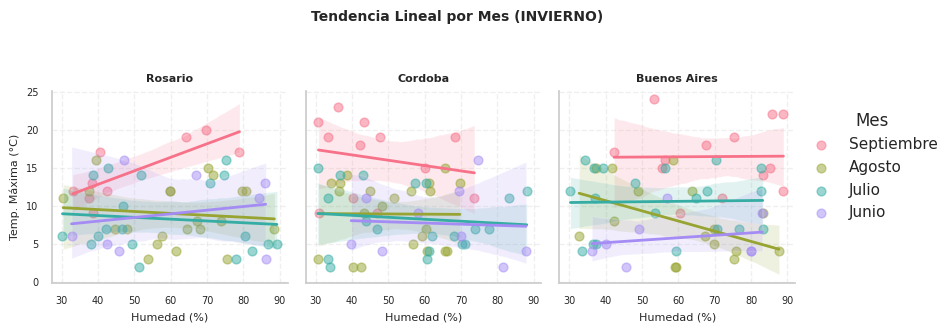

In [ ]:
# --- ANÁLISIS DE INVIERNO ---

# 1. Aseguramos formato datetime
df_final['Date'] = pd.to_datetime(df_final['Date'])

# 2. Diccionario para traducir meses (Invierno)
traduccion_meses = {
    'June': 'Junio', 'July': 'Julio',
    'August': 'Agosto', 'September': 'Septiembre'
}

# Creamos la columna Month y aplicamos la traducción
df_final['Month'] = df_final['Date'].dt.month_name().map(traduccion_meses)

# 3. Filtramos por Ciudad y el rango de Invierno (21 de Junio al 20 de Septiembre)
inicio_estacion = '2023-06-21'
fin_estacion = '2023-09-20'

df_90dias = df_final[
    (df_final['City'].isin(['Cordoba', 'Buenos Aires', 'Rosario'])) &
    (df_final['Date'] >= inicio_estacion) &
    (df_final['Date'] <= fin_estacion)
].copy()

# 4. Graficamos: Una columna por Ciudad, colores por Mes
g = sns.lmplot(data=df_90dias,
                x='Relative Humidity',
                y='Max Temperature',
                hue='Month',
                col='City',
                palette='husl',
                height=3.5, aspect=0.8, # Mismo tamaño compacto que los otros
                scatter_kws={'alpha':0.5, 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES ESTÉTICOS FINALES ---
g.set_axis_labels('Humedad (%)', 'Temp. Máxima (°C)', size=8)
g.set_titles("{col_name}", size=8, fontweight='bold')

plt.subplots_adjust(top=0.75)
g.fig.suptitle('Tendencia Lineal por Mes (INVIERNO)',
               fontsize=10, fontweight='bold')

# Mejorar la leyenda
g._legend.set_title("Mes")

# Ajuste de los valores de la cuadrícula (números legibles pero pequeños)
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()

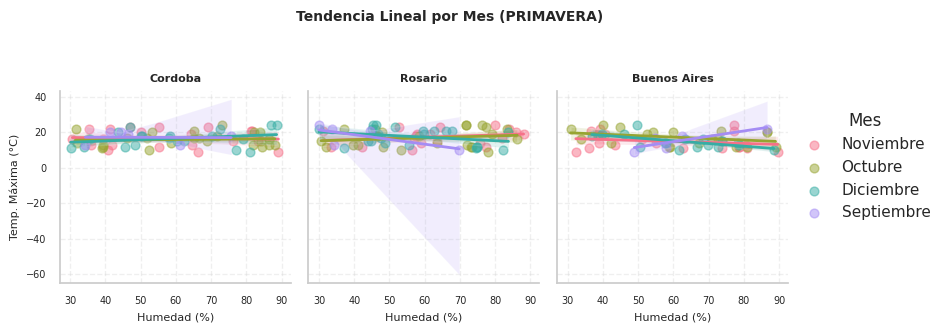

In [ ]:
# --- ANÁLISIS DE PRIMAVERA ---

# 1. Aseguramos formato datetime
df_final['Date'] = pd.to_datetime(df_final['Date'])

# 2. Diccionario para traducir meses (Primavera)
traduccion_meses = {
    'September': 'Septiembre', 'October': 'Octubre',
    'November': 'Noviembre', 'December': 'Diciembre'
}

# Creamos la columna Month y aplicamos la traducción
df_final['Month'] = df_final['Date'].dt.month_name().map(traduccion_meses)

# 3. Filtramos por Ciudad y el rango de Primavera (21 de Septiembre al 31 de Diciembre)
inicio_estacion = '2023-09-21'
fin_estacion = '2023-12-31'

df_90dias = df_final[
    (df_final['City'].isin(['Cordoba', 'Buenos Aires', 'Rosario'])) &
    (df_final['Date'] >= inicio_estacion) &
    (df_final['Date'] <= fin_estacion)
].copy()

# 4. Graficamos con los ajustes de tamaño que venimos usando
g = sns.lmplot(data=df_90dias,
                x='Relative Humidity',
                y='Max Temperature',
                hue='Month',
                col='City',
                palette='husl',
                height=3.5, aspect=0.8, # Tamaño compacto para coherencia visual
                scatter_kws={'alpha':0.5, 's':40},
                line_kws={'linewidth': 2})

# --- AJUSTES ESTÉTICOS FINALES ---
g.set_axis_labels('Humedad (%)', 'Temp. Máxima (°C)', size=8)
g.set_titles("{col_name}", size=8, fontweight='bold')

plt.subplots_adjust(top=0.75)
g.fig.suptitle('Tendencia Lineal por Mes (PRIMAVERA)',
               fontsize=10, fontweight='bold')

# Mejorar la leyenda
g._legend.set_title("Mes")

# Ajuste de los valores de la cuadrícula
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()

En Diciembre hemos contemplado los 31 días como Primavera para no generar otro gráfico.-

In [ ]:
# DataFrame FILTRADO por zona central

# 1. Definimos la lista de ciudades (aseguramos mayúsculas según tu limpieza previa)
zonacentro = ['Cordoba', 'Buenos Aires', 'Rosario']

# 2. Filtramos el DataFrame
df_filtrado = df_final[df_final['City'].isin(zonacentro)]



Líneas de Regresión por Ciudad (lmplot): Agregamos líneas que muestran la tendencia específica de cada ciudad. Por ejemplo, podrías notar que en Rosario la temperatura baja más rápido ante la humedad que en Córdoba.

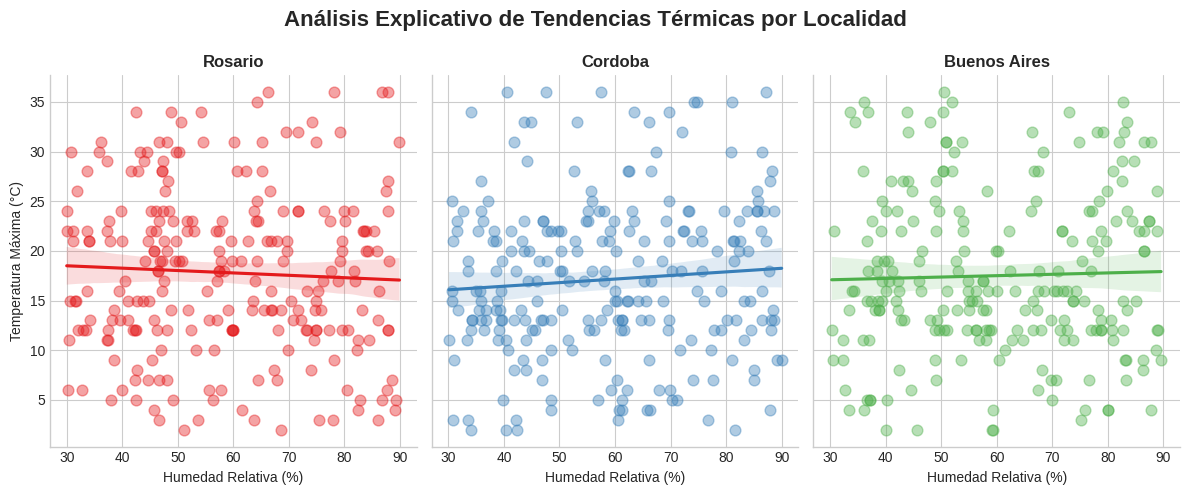

In [ ]:
# --- GRÁFICO EXPLICATIVO DE TENDENCIAS POR PANELES ---

# 1. Usamos lmplot pero con el parámetro 'col' para separar por ciudad
g = sns.lmplot(data=df_filtrado,
               x='Relative Humidity',
               y='Max Temperature',
               col='City',          # Crea un gráfico al lado del otro por ciudad
               hue='City',          # Mantiene los colores por ciudad
               palette='Set1',
               height=5, aspect=0.8,
               scatter_kws={'alpha':0.4, 's':60})
               # line_kws={'color': 'black', 'linewidth': 2}) # Línea negra para que resalte la tendencia

# 2. Ajustes de títulos y etiquetas para claridad
g.set_axis_labels("Humedad Relativa (%)", "Temperatura Máxima (°C)")
g.set_titles("{col_name}", weight='bold', size=12)

# Añadimos un título general al conjunto de gráficos
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Análisis Explicativo de Tendencias Térmicas por Localidad', fontsize=16, fontweight='bold')

plt.show()

Inclinación de la línea de tendencia:
Pendiente de la Línea: Si la línea de una ciudad está más inclinada hacia abajo que la otra, significa que en esa ciudad la temperatura cae más drásticamente cuando aumenta la humedad.
Dispersión: Notar si los puntos están muy pegados a la línea (relación fuerte) o muy desparramados (relación débil).

/tmp/ipykernel_642/575280760.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='City', y='Max Temperature',


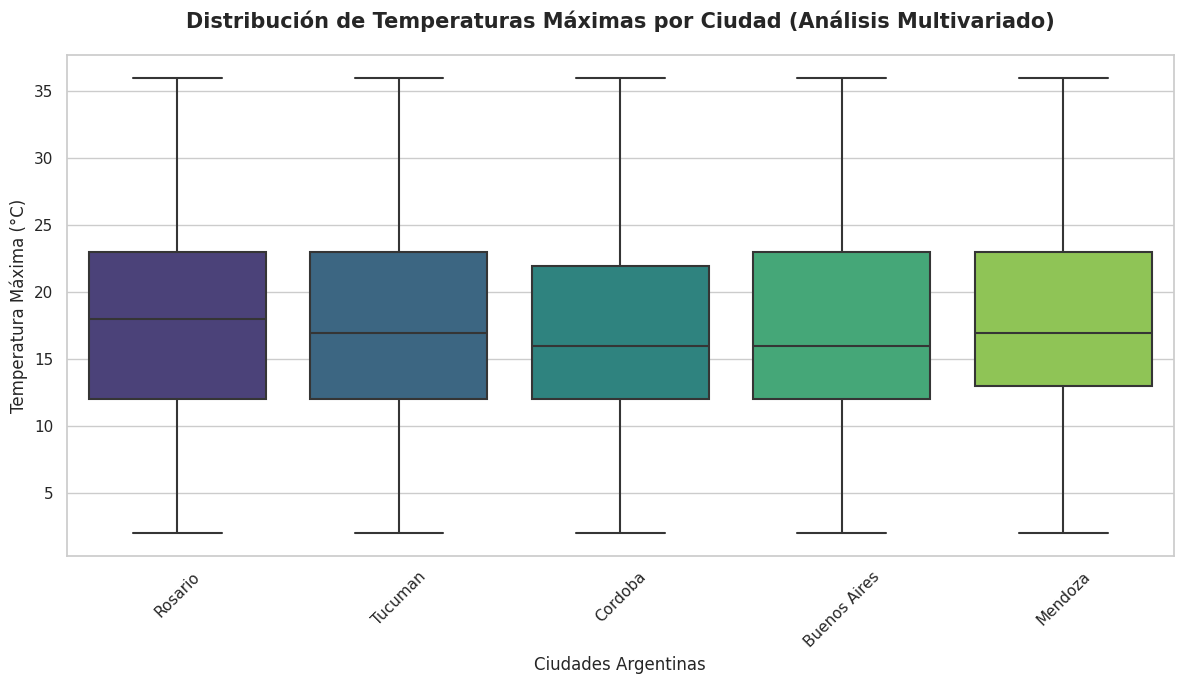

In [ ]:
# --- ANÁLISIS MULTIVARIADO: BOXPLOT + SWARMPLOT ---
plt.figure(figsize=(12, 7))

# 1. Definimos un estilo de fondo limpio
sns.set_theme(style="whitegrid")

# 2. Creamos el Boxplot con un diseño más moderno
# Usamos 'whis=1.5' para la detección estándar de outliers
sns.boxplot(data=df_final, x='City', y='Max Temperature',
            palette='viridis', fliersize=5, linewidth=1.5)

# 4. Personalización estética
plt.title('Distribución de Temperaturas Máximas por Ciudad (Análisis Multivariado)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Ciudades Argentinas', fontsize=12)
plt.ylabel('Temperatura Máxima (°C)', fontsize=12)

# 5. Rotamos los nombres de las ciudades si son largos para que no se solapen
plt.xticks(rotation=45)

# Mejoramos el ajuste para que no se corte nada
plt.tight_layout()
plt.show()

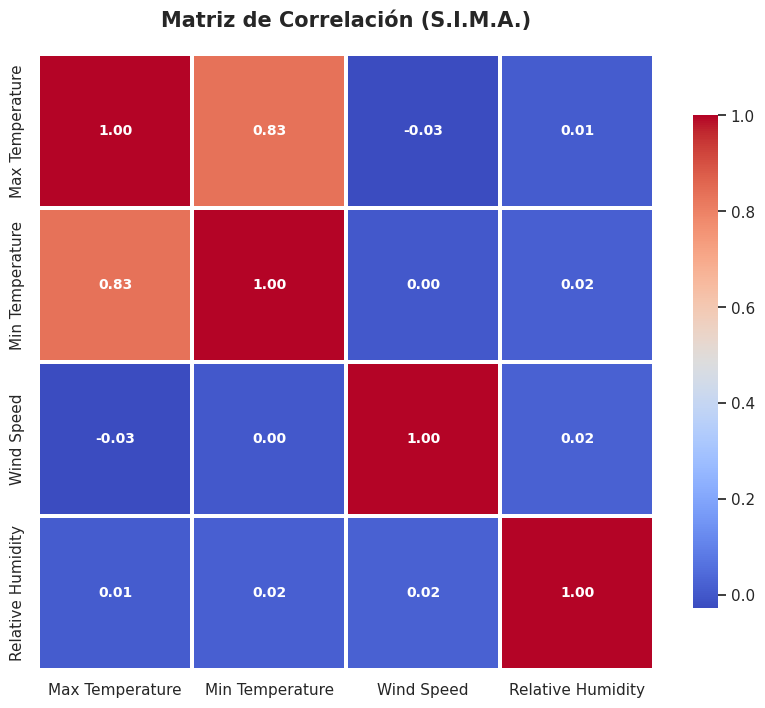

In [ ]:
# --- ANÁLISIS MULTIVARIADO: MATRIZ DE CORRELACIÓN ---
plt.figure(figsize=(10, 8))

correlaciones = df_final[cols_numericas].corr()

# Dibujamos el Heatmap COMPLETO con mejoras de legibilidad
sns.heatmap(correlaciones,
            annot=True,          # Muestra los valores numéricos
            cmap='coolwarm',     # Mantenemos tu paleta original o 'RdBu_r'
            fmt=".2f",           # Formato de dos decimales
            linewidths=1.5,      # Aumentamos la separación entre cuadros para que no se peguen
            linecolor='white',   # Color de la línea divisoria
            square=True,         # Mantiene las celdas cuadradas para mejor estética
            cbar_kws={"shrink": .8}, # Ajusta el tamaño de la barra de intensidad
            annot_kws={"size": 10, "weight": "bold"}) # Resalta los números dentro de la matriz

plt.title('Matriz de Correlación (S.I.M.A.)', fontsize=15, fontweight='bold', pad=20)
plt.show()

In [ ]:
df_final.head(11)

,Date,City,Max Temperature,Min Temperature,Wind Speed,Relative Humidity,Month
0,2023-09-18,Rosario,17.0,10.0,19.0,40.5,September
1,2023-02-01,Tucuman,26.0,19.0,35.6,83.4,February
2,2023-11-23,Cordoba,22.0,15.0,19.0,35.3,November
4,2023-10-18,Rosario,22.0,5.0,33.1,46.0,October
8,2023-08-27,Cordoba,2.0,-2.0,34.1,42.4,August
10,2023-05-14,Rosario,24.0,13.0,13.4,63.7,May
13,2023-12-22,Cordoba,20.0,14.0,33.7,43.7,December
14,2023-10-06,Buenos Aires,16.0,13.0,35.7,72.6,October
17,2023-02-08,Tucuman,25.0,19.0,34.0,85.4,February
18,2023-07-13,Cordoba,11.0,8.0,38.1,83.3,July


In [ ]:
df_final.describe()

,Date,Max Temperature,Min Temperature,Wind Speed,Relative Humidity
count,1191,1191.000000,1191.000000,1191.000000,1191.000000
mean,2023-07-02 07:49:07.103274496,17.600336,10.096558,24.974475,59.628799
min,2023-01-01 00:00:00,2.000000,-3.000000,10.000000,30.000000
25%,2023-04-04 00:00:00,12.000000,6.000000,17.800000,44.500000
50%,2023-06-29 00:00:00,17.000000,10.000000,24.900000,59.000000
75%,2023-10-02 00:00:00,23.000000,15.000000,32.300000,74.800000
max,2023-12-31 00:00:00,36.000000,22.000000,40.000000,90.000000
std,NaN,7.988530,6.485659,8.555611,17.384428


In [ ]:
# --- CONTROL DE CALIDAD FINAL ---

# 1. Comprobación real de nulos (Debe dar todo 0)
print("Conteo de nulos por columna:")
print(df_final.isnull().sum())

# 2. Limpieza visual de la fecha (solo para verla sin la hora)
# Esto solo cambia CÓMO SE VE, no el tipo de dato
df_final['Date'] = df_final['Date'].dt.date

# 3. Verificación de tipos de datos
print("\nTipos de datos finales:")
print(df_final.dtypes)

# Mostramos los primeros 5 para ver que la fecha esté linda
display(df_final.head())

Conteo de nulos por columna:
Date                 0
City                 0
Max Temperature      0
Min Temperature      0
Wind Speed           0
Relative Humidity    0
Month                0
dtype: int64

Tipos de datos finales:
Date                  object
City                  object
Max Temperature      float64
Min Temperature      float64
Wind Speed           float64
Relative Humidity    float64
Month                 object
dtype: object


,Date,City,Max Temperature,Min Temperature,Wind Speed,Relative Humidity,Month
0,2023-09-18,Rosario,17.0,10.0,19.0,40.5,September
1,2023-02-01,Tucuman,26.0,19.0,35.6,83.4,February
2,2023-11-23,Cordoba,22.0,15.0,19.0,35.3,November
4,2023-10-18,Rosario,22.0,5.0,33.1,46.0,October
8,2023-08-27,Cordoba,2.0,-2.0,34.1,42.4,August


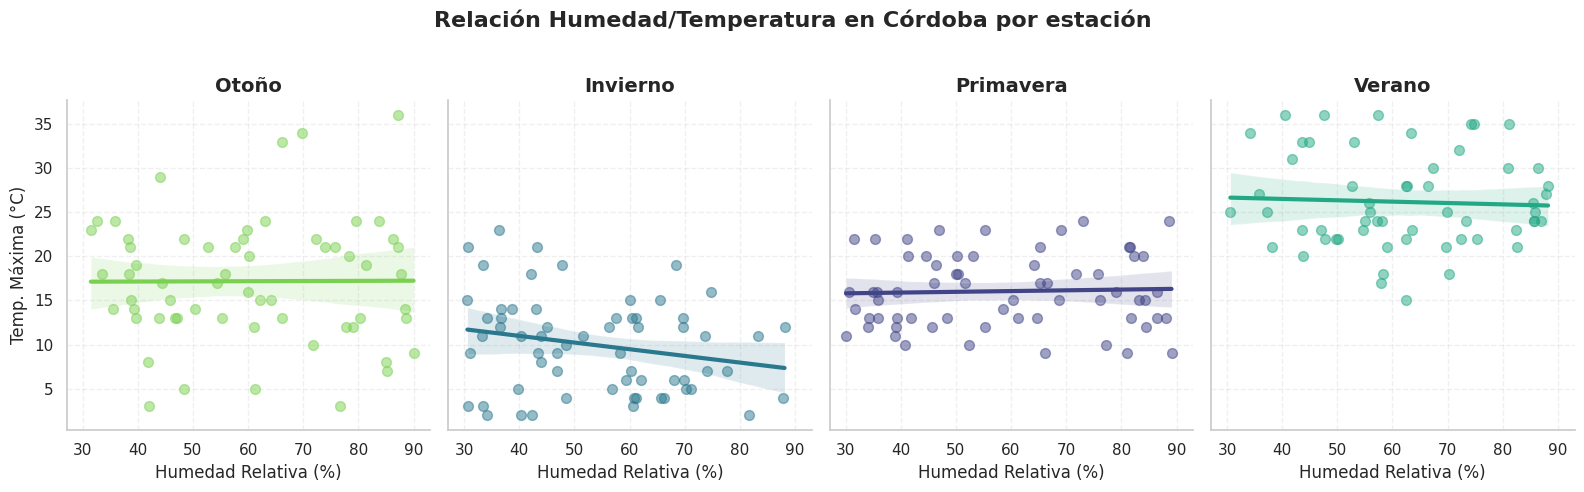

In [ ]:
# --- COMPARATIVA DE CÓRDOBA ---
# 1. Definimos estaciones
def asignar_estacion(fecha):
    mes = fecha.month
    dia = fecha.day
    if (mes == 12 and dia >= 21) or (mes <= 2) or (mes == 3 and dia < 21):
        return 'Verano'
    elif (mes == 3 and dia >= 21) or (mes <= 5) or (mes == 6 and dia < 21):
        return 'Otoño'
    elif (mes == 6 and dia >= 21) or (mes <= 8) or (mes == 9 and dia < 21):
        return 'Invierno'
    else:
        return 'Primavera'

# 2. Aplicamos la función y filtramos solo Córdoba
df_final['Season'] = df_final['Date'].apply(asignar_estacion)
df_cba = df_final[df_final['City'] == 'Cordoba'].copy()

# 3. Ordenamos las estaciones para que aparezcan en orden lógico
orden_estaciones = ['Otoño', 'Invierno', 'Primavera', 'Verano']

# 4. Graficamos
g = sns.lmplot(data=df_cba,
               x='Relative Humidity',
               y='Max Temperature',
               col='Season',
               col_order=orden_estaciones,
               hue='Season',
               palette='viridis',
               height=5, aspect=0.8,
               scatter_kws={'alpha':0.5, 's':50},
               line_kws={'linewidth': 3})

# AJUSTES FINALES
g.set_axis_labels('Humedad Relativa (%)', 'Temp. Máxima (°C)')
g.set_titles("{col_name}", size=14, fontweight='bold')
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Relación Humedad/Temperatura en Córdoba por estación',
               fontsize=16, fontweight='bold')

for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)

plt.show()